In [358]:
import os
import sys

sys.path.append("..")
import torch

In [359]:
with open("../Log/exp_32_best/output_log.txt") as f:
    lines = f.readlines()

flag = False
layer0_result_dicts = {
    "Epoch": [],
    "num_neurons_layer_0": [],
    "dup_neurons_layer_0": [],
    "del_neurons_layer_0": [],
}
for line in lines:
    if line.split(":")[0] == "Epoch":
        if flag == False:
            layer0_result_dicts["Epoch"].append(int(line.split(":")[1]))
            flag = True
        else:
            flag = False
    elif line.split(":")[0] == "num_neurons_layer_0":
        layer0_result_dicts["num_neurons_layer_0"].append(
            int(line.split(":")[1].split("(")[1][:-2])
        )
    elif line.split(":")[0] == "dup_neurons_layer_0":
        layer0_result_dicts["dup_neurons_layer_0"].append(
            int(float(line.split(":")[1][:-1]))
        )
    elif line.split(":")[0] == "del_neurons_layer_0":
        layer0_result_dicts["del_neurons_layer_0"].append(
            int(float(line.split(":")[1][:-1]))
        )
    else:
        continue

/tmp/ipykernel_635481/3454006973.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20c')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


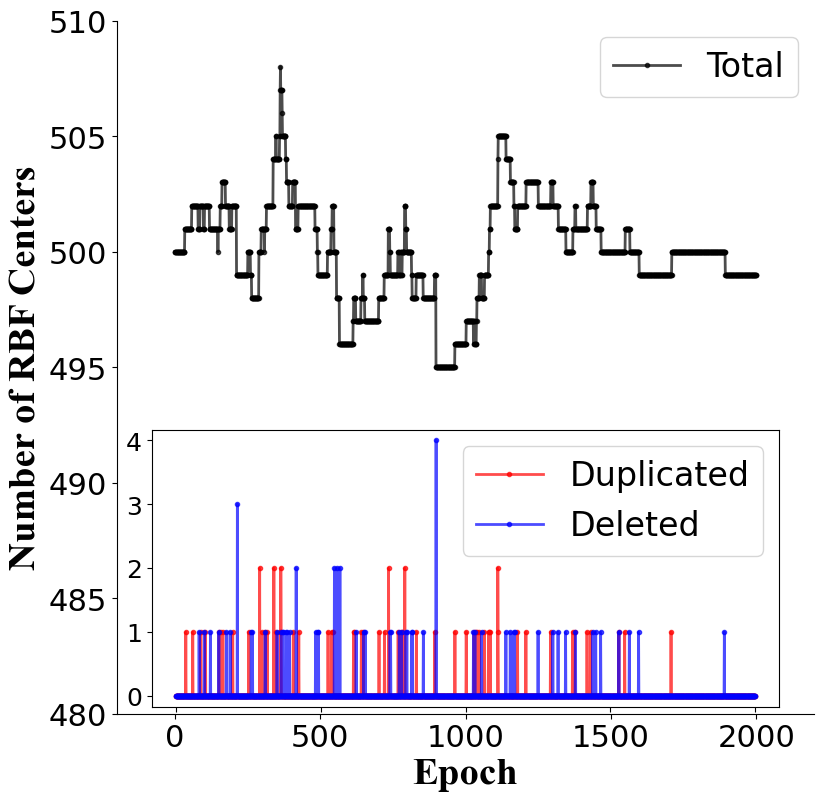

In [366]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1, 1, figsize=(9,9))

cmap = plt.cm.get_cmap('tab20c')
colors = cmap(np.linspace(0, 1, 3))

ax.margins(x=0.1, y=0.1)
ax.set_xlabel('Epoch', fontdict={"family": "Times New Roman","weight": "bold", "size": 28})
ax.set_ylabel('Number of RBF Centers', fontdict={"family": "Times New Roman","weight": "bold", "size": 28})
ax.tick_params(axis='x', labelsize=22)
ax.tick_params(axis='y', labelsize=22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(480, 510)
ax.plot(layer0_result_dicts["Epoch"], layer0_result_dicts["num_neurons_layer_0"], marker='.', color="k", alpha=0.7, linewidth=2, linestyle='-')

# ax.grid(ls="-.", lw=0.5, c="grey")
ax.legend()

axins1 = inset_axes(ax, width="90%", height="40%", loc='upper left', bbox_to_anchor=(0.04, -0.58, 1, 1), bbox_transform=ax.transAxes)
axins1.plot(layer0_result_dicts["Epoch"], layer0_result_dicts["dup_neurons_layer_0"], marker='.', color="r", alpha=0.7, linewidth=2, linestyle='-')
axins1.plot(layer0_result_dicts["Epoch"], layer0_result_dicts["del_neurons_layer_0"], marker='.', color="b", alpha=0.7, linewidth=2, linestyle='-')

# axins1.set_ylim(-0.5, 12)
axins1.tick_params(axis='x', labelsize=18)
axins1.set_xticklabels([])
axins1.tick_params(axis='y', labelsize=18)
axins1.yaxis.set_major_locator(MaxNLocator(integer=True))
# axins1.grid(ls="-.", lw=0.5, c="grey")
axins1.margins(x=0.042, y=0.042)

ax.legend(["Total"], prop={'size':24})
axins1.legend([ "Duplicated", "Deleted"], prop={'size':24})
plt.savefig('TE_Neuron_Adj.svg', bbox_inches='tight', pad_inches=0, dpi=1200)
plt.show()

In [275]:
from model import FF_TE
from config import config

train_set = FF_TE.FF_TE("train")
val_set = FF_TE.FF_TE("val")
test_set = FF_TE.FF_TE("test")
trn_loader = torch.utils.data.DataLoader(
    train_set,
    config.batch_size,
    drop_last=False,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)
val_loader = torch.utils.data.DataLoader(
    val_set,
    config.batch_size,
    drop_last=True,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)
tst_loader = torch.utils.data.DataLoader(
    test_set,
    config.batch_size,
    drop_last=True,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

In [276]:
import torch
from model import FF_RBF, utils

model = torch.load("../Log/exp_14/output_model.pth").to(torch.device(config.device))
with torch.no_grad():
    output = []
    pos_embeddings = []
    neg_embeddings = []
    target = []
    for inputs, labels in tst_loader:
        inputs, labels = utils.preprocess_inputs(inputs, labels)

        pos_z, neg_z = model.embedding(inputs)
        pos_embeddings.append(pos_z)
        neg_embeddings.append(neg_z)
        scarlar_output = model.forward_downstream_classification_model(inputs, labels)
        output.append(scarlar_output["output"].detach().argmax(dim=1, keepdim=False))
        target.append(labels["class_labels"].detach())
    output = torch.concat(output, dim=0)
    pos_embeddings = torch.cat(pos_embeddings, dim=0)
    neg_embeddings = torch.cat(neg_embeddings, dim=0)
    target = torch.concat(target, dim=0)

    print(output.shape, target.shape)

/ExtHDD/Users/Astroyd/SORBF/writing/../model/FF_TE.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(class_label), num_classes=self.num_classes


torch.Size([400]) torch.Size([400])


In [277]:
def confusion_matrix(preds, labels, conf_matrix):
    for p, t in zip(preds, labels):
        conf_matrix[p, t] += 1
    return conf_matrix

In [278]:
conf_matrix = torch.zeros(4, 4)
conf_matrix = confusion_matrix(output, target, conf_matrix).cpu().numpy()
print(conf_matrix)

[[ 81.   8.   1.   0.]
 [ 12.  73.  10.   0.]
 [  1.  11.  82.   7.]
 [  0.   0.   7. 107.]]


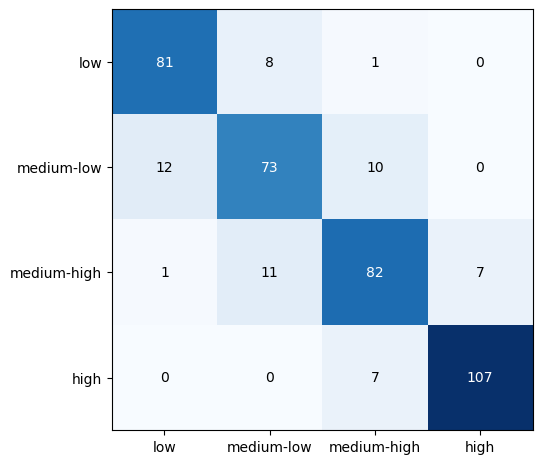

In [279]:
labels_text = ["low", "medium-low", "medium-high", "high"]
plt.imshow(conf_matrix, cmap=plt.cm.Blues)

thresh = conf_matrix.max() / 2
for x in range(4):
    for y in range(4):
        info = int(conf_matrix[y, x])
        plt.text(
            x,
            y,
            info,
            verticalalignment="center",
            horizontalalignment="center",
            color="white" if info > thresh else "black",
        )

plt.tight_layout()
plt.yticks(range(4), labels_text)
plt.xticks(range(4), labels_text)
plt.show()
plt.close()

In [280]:
embeddings = torch.concat([pos_embeddings, neg_embeddings], dim=0).cpu().numpy()
labels = np.ones(embeddings.shape[0])
labels[: neg_embeddings.shape[0]] = 0


from sklearn.manifold import TSNE

X_embedded = TSNE(
    n_components=2,
    learning_rate=800,
    perplexity=35,
    max_iter=2500,
    early_exaggeration=7,
).fit_transform(embeddings)
X_norm = (X_embedded - X_embedded.min(0)) / (X_embedded.max(0) - X_embedded.min(0))

/tmp/ipykernel_635481/1482511707.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("Dark2")
/tmp/ipykernel_635481/1482511707.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/tmp/ipykernel_635481/1482511707.py:25: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


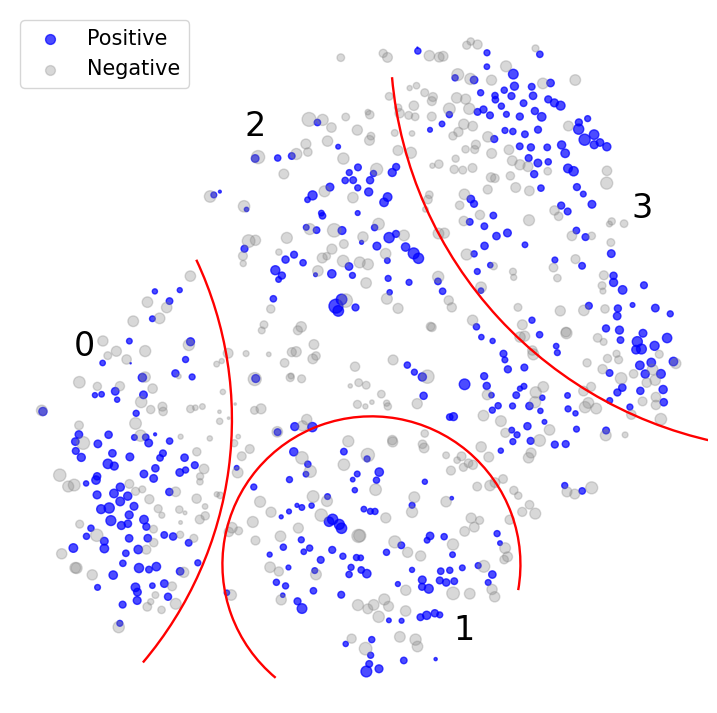

In [357]:
import matplotlib.patches as patches

cmap = plt.cm.get_cmap("Dark2")
colors = cmap(np.linspace(0, 1, 2))

sizes_pos = torch.sum(pos_embeddings**2, dim=1).cpu().numpy()
sizes_pos = (sizes_pos - np.amin(sizes_pos, axis=0)) / (
    np.amax(sizes_pos, axis=0) - np.amin(sizes_pos, axis=0)
)
sizes_neg = torch.sum(neg_embeddings**2, dim=1).cpu().numpy()
sizes_neg = (sizes_neg - np.amin(sizes_neg, axis=0)) / (
    np.amax(sizes_neg, axis=0) - np.amin(sizes_neg, axis=0)
)

plt.figure(figsize=(9, 9))
plt.scatter(
    X_norm[: pos_embeddings.shape[0], 0],
    X_norm[: pos_embeddings.shape[0], 1],
    c="b",
    alpha=0.7,
    s=sizes_pos * 100,
    label="Positive",
    cmap="Dark2",
)
plt.scatter(
    X_norm[pos_embeddings.shape[0] :, 0],
    X_norm[pos_embeddings.shape[0] :, 1],
    c="grey",
    alpha=0.3,
    s=sizes_neg * 100,
    label="Negative",
    cmap="Dark2",
)
plt.xticks([])
plt.yticks([])
# for i in range(pos_embeddings.shape[0]):
#     plt.text(X_norm[i, 0], X_norm[i, 1], str(target[i].item()))

arc1 = patches.Arc((-0.3, 0.4), 1.2, 1.2, color="r", theta1=-40, theta2=25, lw=1.7)
plt.gcf().gca().add_artist(arc1)

arc2 = patches.Arc((0.52, 0.17), 0.47, 0.47, color="r", theta1=-10, theta2=230, lw=1.7)
plt.gcf().gca().add_artist(arc2)

arc3 = patches.Arc((1.2, 1.0), 1.3, 1.3, color="r", theta1=185, theta2=260, lw=1.7)
plt.gcf().gca().add_artist(arc3)

plt.text(0.05, 0.5, str(0), fontdict={"size": 24})
plt.text(0.65, 0.05, str(1), fontdict={"size": 24})
plt.text(0.32, 0.85, str(2), fontdict={"size": 24})
plt.text(0.93, 0.72, str(3), fontdict={"size": 24})

for spine in plt.gcf().gca().spines.values():
    spine.set_visible(False)

plt.legend(prop={"size": 15})
plt.savefig("TE_ARBF_Embedding.svg", bbox_inches="tight", pad_inches=0, dpi=1200)

In [368]:
models = [
    "ANN",
    "NB",
    "DT",
    "BP-FNN",
    "FF-FNN",
    "VAE",
    "SAE",
    "MAE",
    "GM-OSRBF",
    "IOS-RBF",
    "FF-ARBF",
]
indices = ["Accuracy(%)", "Kappa(%)", "macF1(10E-2)", "AUC(10E-2)"]
results = [
    [73.75, 73.28, 73.75, 82.89],
    [79.50, 79.61, 79.50, 87.48],
    [78.50, 77.51, 78.50, 85.06],
    [83.50, 83.05, 78.31, 94.65],
    [84.00, 84.68, 80.29, 95.18],
    [84.24, 84.82, 80.65, 95.72],
    [86.42, 86.91, 81.46, 97.48],
    [84.91, 85.37, 81.13, 96.08],
    [85.73, 86.01, 79.46, 96.95],
    [86.81, 86.97, 82.53, 97.91],
    [87.67, 88.17, 83.49, 98.25],
]
errors = [
    [0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0],
    [0.92, 1.01, 1.01, 0.07],
    [1.07, 0.77, 1.19, 0.07],
    [0.76, 0.86, 0.94, 0.06],
    [0.66, 0.75, 0.59, 0.04],
    [0.71, 0.61, 1.05, 0.06],
    [0.46, 0.79, 0.92, 0.07],
    [0.76, 1.15, 1.15, 0.05],
    [0.64, 0.91, 0.80, 0.06],
]
results = [list(row) for row in zip(*results)]
errors = [list(row) for row in zip(*errors)]

/tmp/ipykernel_635481/1723967107.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('tab20')


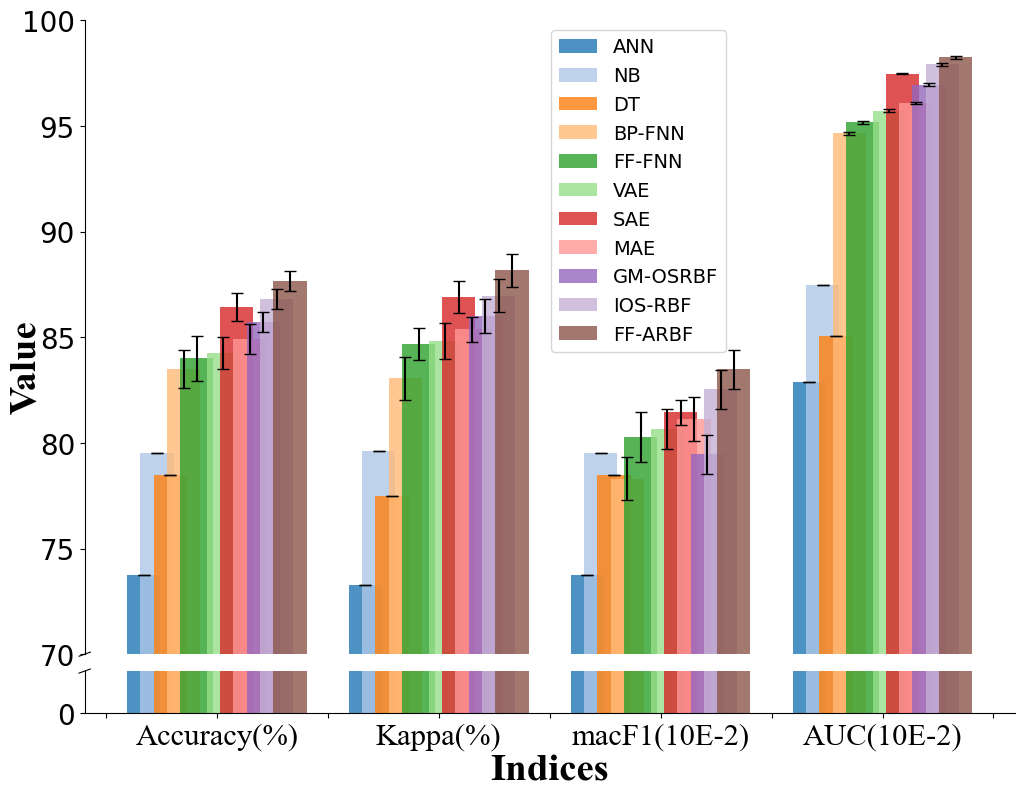

In [418]:
%matplotlib inline
from brokenaxes import brokenaxes

x = np.arange(len(indices))
width = 0.15
opacity = 0.8
fig = plt.figure(figsize=(12, 9))
ax = brokenaxes(ylims=[(0, 2), (70, 100)], despine=True, hspace=0.05, d=0.005, tilt=20)
# ax.spines["right"].set_visible(False)
# ax.spines["top"].set_visible(False)
cm = plt.cm.get_cmap('tab20')

rectsANN = ax.bar(x - width * 11 / 5, [result[0] for result in results], yerr=[error[0] for error in errors], label="ANN", capsize=4, width=width, alpha=opacity, color=cm(0))
rectsNB = ax.bar(x - width * 9 / 5, [result[1] for result in results], yerr=[error[1] for error in errors], label="NB", capsize=4, width=width, alpha=opacity, color=cm(1))
rectsDT = ax.bar(x - width * 7 / 5, [result[2] for result in results], yerr=[error[2] for error in errors], label="DT", capsize=4, width=width, alpha=opacity, color=cm(2))
rectsBPFNN = ax.bar(x - width * 5 / 5, [result[3] for result in results], yerr=[error[3] for error in errors], label="BP-FNN", capsize=4, width=width, alpha=opacity, color=cm(3))
rectsFFFNN = ax.bar(x - width * 3 / 5, [result[4] for result in results], yerr=[error[4] for error in errors], label="FF-FNN", capsize=4, width=width, alpha=opacity, color=cm(4))
rectsVAE = ax.bar(x + width   / 5, [result[5] for result in results], yerr=[error[5] for error in errors], label="VAE", capsize=4, width=width, alpha=opacity, color=cm(5))
rectsSAE = ax.bar(x + width * 3 / 5, [result[6] for result in results], yerr=[error[6] for error in errors], label="SAE", capsize=4, width=width, alpha=opacity, color=cm(6))
rectsMAE = ax.bar(x + width * 5 / 5, [result[7] for result in results], yerr=[error[7] for error in errors], label="MAE", capsize=4, width=width, alpha=opacity, color=cm(7))
rectsGMOSRBF = ax.bar(x + width * 7 / 5, [result[8] for result in results], yerr=[error[8] for error in errors], label="GM-OSRBF", capsize=4, width=width, alpha=opacity, color=cm(8))
rectsIOSRBF = ax.bar(x + width * 9 / 5, [result[9] for result in results], yerr=[error[8] for error in errors], label="IOS-RBF", capsize=4, width=width, alpha=opacity, color=cm(9))
rectsFFARBF = ax.bar(x + width * 11 / 5, [result[10] for result in results], yerr=[error[8] for error in errors], label="FF-ARBF", capsize=4, width=width, alpha=opacity, color=cm(10))

# ax.set_title("Classification Results", fontdict={'family' : 'Times New Roman', 'weight': 'bold', 'size'   : 16})
ax.set_xlabel("Indices", fontdict={'family' : 'Times New Roman', 'weight': 'bold', 'size'   : 28}, labelpad=30)
ax.set_ylabel("Value", fontdict={'family' : 'Times New Roman', 'weight': 'bold', 'size'   : 28})

ax.set_xticks(x, indices, fontsize=12, fontdict={'family' : 'Times New Roman', 'size'   : 22})
ax.tick_params(axis='y', labelsize=20)


ax.legend(bbox_to_anchor=(0.7, 1), prop={"size": 14})

plt.savefig("./TE_Error_Bars.svg", bbox_inches="tight", pad_inches=0, dpi=1200)
plt.show()